### Classification of cellular states in PAAD tumor-model pairs

This notebook provides an example for the analysis of PAAD pairs shown in Fig. 5 and Extended Data Fig. 7

Setup user-defined parameters. Provide the full path to "HCMI_snRNAseq_data_metadata" as `Work_dir` and the full path to the current GitHub (parent) directory as `Code_dir`.

In [1]:
cohort = "PDAC"

Work_dir = "/groups/ac2248_gp/shares/hcmi/single-nuclei/HCMI_snRNAseq_data_metadata/" # parent directory for input data
Code_dir = "/groups/ac2248_gp/lz2841/ColumbiaProjects/hcmi-analysis-califano-lab/" # path to GitHub folder

Other settings include the reference population for data centering and scaling, number of target genes per regulon in regulatory networks, set of regulators used in reverse-engineering of gene regulatory networks and graphic parameters.

`run_protein_activity` allows the user to generate a protein activity matrix for VIPER analysis. This is set to False by default, and a pre-computed protein activity matrix is loaded for the purpose.

In [2]:
reference = "cells_from_model" 

pval_NaRnEA=0.15
reg_set = "all-regs" # "tf-cotfs" "all-regs"
n_targets_VIPER = 100 # number o target genes per regulator in network pruning
n_PDAC = 50 # number of regulator per subtype signature
NN_vector = 15 # number of NNs for functions where this is required


run_dim_red = False
binary_output = False # output for the NaRnEA heatmap
include_unknown_barplots = False

run_protein_activity = False

Paths to directory collecting markers and demultiplexed input data are specified below.

In [3]:
filtering_level_vcf = "filtered_01" # "no_filtered": VCFs; "filtered": VCFs filtered at MAF>=1%, "filtered_01": VCFs filtered at MAF >=0.1%
sample_assignment = "best_gt_thresh" # "best_gt_thresh"; "sng1st_gt" 


# Postprocessing filtering_level_vcf
if filtering_level_vcf == "no_filtered":
    filtering_level_vcf = ""
elif filtering_level_vcf == "filtered":
    filtering_level_vcf = "-filtered"
elif filtering_level_vcf == "filtered_01":
    filtering_level_vcf = "-filtered-01"
else:
    print("Unknown value provided for filtering_level_vcf")


markers_dir = f"{Code_dir}single-nuclei/markers/" # path to directory collecting gene expression markers


Specify the cases ID in the cohort.

In [4]:
cases=["HCM-CSHL-0073-C25", "HCM-CSHL-0078-C25", "HCM-CSHL-0089-C25", "HCM-BROD-0110-C25"]

Import packages and custom functions

In [5]:
import sys
import scanpy as sc
import numpy as np 
from numpy import nanmedian, NaN
import pandas as pd
import os 
from matplotlib import rc_context
import seaborn as sns
import matplotlib.pyplot as plt
import pyviper
import acdc_py as acdc 
sc.settings.verbosity = 0
sc.logging.print_header()
sc.settings.set_figure_params(frameon=False, dpi=100, facecolor="white")
from matplotlib_venn import venn2, venn3
from sklearn.metrics import silhouette_samples
from matplotlib.backends.backend_pdf import PdfPages
import hdf5plugin
import anndata
import gc
from contextlib import contextmanager
import warnings
warnings.simplefilter("ignore", category=UserWarning)
from scipy.sparse import issparse
import re
from matplotlib.colors import LinearSegmentedColormap
from itertools import compress
from scipy.stats import combine_pvalues
from openpyxl import Workbook
sys.path.append(f'{Code_dir}/single-nuclei/funcs/')
from processing_funcs import *
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import math

import marsilea as ma
import marsilea.plotter as mp
from matplotlib.patches import Rectangle

# Custom function: retrieving putative malignant cells
def process_clusters(clusters_putative_malignant):
    # Extract the value from the Series (assuming a single element in the Series)
    cluster_value = clusters_putative_malignant.values[0]
    
    # Check if the value is "all"
    if isinstance(cluster_value, str) and cluster_value.lower() == "all":
        return cluster_value
    # If it's a comma-separated string, split it into a list of integers
    elif isinstance(cluster_value, str) and "," in cluster_value:
        return [int(i) for i in cluster_value.split(",")]
    # If it's a single integer, wrap it in a list
    else:
        return [int(cluster_value)]


# Specify other graphic parameters
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7

scanpy==1.10.2 anndata==0.10.8 umap==0.5.6 numpy==1.24.3 scipy==1.12.0 pandas==2.2.2 scikit-learn==1.5.1 statsmodels==0.14.2 igraph==0.11.6 pynndescent==0.5.13


Load snRNA-seq metadata

In [6]:
snRNAseq_metadata_path = f"{Code_dir}single-nuclei/Matched Model_Tumor for Sequencing.xlsx"
snRNAseq_metadata = pd.read_excel(snRNAseq_metadata_path, sheet_name="Samplesheet_for_Analysis")

Load snRNA-seq data and subset for putative malignant cells only

In [7]:
adata_samples = {}  # initialize dictionary collecting AnnData object
samples_metadata_path = f"{Work_dir}/metadata/" # path to gene expression metadata

for case in cases:

    print(f"Case: {case}")

    case_metadata = snRNAseq_metadata[snRNAseq_metadata["Case ID"] == case] # subset for the Case ID being analyzed
    
    # Automatically define sample names and paths to data
    samples = [f'{case_metadata.loc[idx,"Multiplex (GEM) ID"]}_{case}' for idx in case_metadata.index] # samples names
    file_paths = {ID: f"{Work_dir}demultiplexed_samples_{sample_assignment}{filtering_level_vcf}/{ID}_gt.h5ad" for ID in samples} # path to data

    # Load snRNA-seq metadata
    for sample, path in file_paths.items():
        # Load gene expression data and include it into AnnData object
        print('Loading ID',sample,end=' ')
        adata_samples[sample] = sc.read_h5ad(filename=path) # adata
        adata_samples[sample].var_names_make_unique()
        adata_samples[sample].obs["Sample Type"] = adata_samples[sample].obs["Sample Type"].str.rstrip() # strip spaces from Sample Type
        print(': AnnData of dimensions',adata_samples[sample].shape)
        # Subset for only the cells that previously passed QC and then only for putative malignant cells
        sample_metadata_path = f"{samples_metadata_path}{sample}-metadata.tsv"
        sample_infercnv_path = f"{samples_metadata_path}{sample}-chrs-infercnv.tsv"
        clusters_putative_malignant = case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Putative malignant clusters"]

        sample_metadata = pd.read_csv(sample_metadata_path, sep="\t")
        sample_infercnv = pd.read_csv(sample_infercnv_path, sep="\t")


        columns_to_add_metadata = sample_metadata.columns.difference(adata_samples[sample].obs.columns)
        sample_metadata = sample_metadata[columns_to_add_metadata]

        # subset for cells retained in the metadata table
        print("Subsetting only for putative tumor cells")

        cohort = list(case_metadata[case_metadata["Sample ID snRNAseq"] == sample]["Cohort"])[0]

        adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs.index.isin(sample_metadata["barcode"])]
        adata_samples[sample].obs = adata_samples[sample].obs.merge(sample_metadata, left_on='barcode', right_on="barcode", how='left') # attach metadata
        # subset of only putative malignant cells
        clusters_putative_malignant = process_clusters(clusters_putative_malignant)
        if clusters_putative_malignant != "all":
            adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["clusters"].isin(clusters_putative_malignant)]

            if cohort == "PDAC":
                adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
                adata_samples[sample] = adata_samples[sample][adata_samples[sample].obs["singler_BpE_cg"] == "Epithelial cells"]

        adata_samples[sample].obs.set_index("barcode", inplace=True) # set index
        sc.pp.calculate_qc_metrics(adata_samples[sample], qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)


    # Gene selection
    gene_names = adata_samples[sample].var_names # assume gene names are the same across all samples
    gene_counts = np.zeros(len(gene_names))
    # Iterate over each sample and accumulate the counts
    for sample, adata in adata_samples.items():
        if issparse(adata.X):
            gene_counts += np.array(adata.X.sum(axis=0)).flatten()
        else:
            gene_counts += np.sum(adata.X, axis=0)
    # Convert to DataFrame for better readability
    gene_counts_df = pd.DataFrame(data=gene_counts, index=gene_names, columns=['Total_Counts'])
    genes_retain = gene_counts_df[gene_counts_df["Total_Counts"] >= 10].index.to_list() # genes to retain 
    genes_retain = [str(gene) for gene in genes_retain]

    del gene_names, gene_counts, gene_counts_df
    gc.collect()

Case: HCM-CSHL-0073-C25
Loading ID AG008_HCM-CSHL-0073-C25 : AnnData of dimensions (3396, 38606)
Subsetting only for putative tumor cells
Loading ID AG009_HCM-CSHL-0073-C25 : AnnData of dimensions (5342, 38606)
Subsetting only for putative tumor cells
Case: HCM-CSHL-0078-C25
Loading ID AG010_HCM-CSHL-0078-C25 : AnnData of dimensions (4837, 38606)
Subsetting only for putative tumor cells
Loading ID AG011_HCM-CSHL-0078-C25 : AnnData of dimensions (7911, 38606)
Subsetting only for putative tumor cells
Loading ID AG012_HCM-CSHL-0078-C25 : AnnData of dimensions (7689, 38606)
Subsetting only for putative tumor cells
Loading ID AG013_HCM-CSHL-0078-C25 : AnnData of dimensions (3345, 38606)
Subsetting only for putative tumor cells
Case: HCM-CSHL-0089-C25
Loading ID AG010_HCM-CSHL-0089-C25 : AnnData of dimensions (6755, 38606)
Subsetting only for putative tumor cells
Loading ID AG011_HCM-CSHL-0089-C25 : AnnData of dimensions (12638, 38606)
Subsetting only for putative tumor cells
Loading ID AG01

Perform gene filtering and concatenate samples 

In [8]:
samples = list(adata_samples.keys())

for sample in samples:
    print(f"Gene filtering for {sample}")
    adata_samples[sample] = adata_samples[sample][:, genes_retain]


# Samples concatenation
adata_all = sc.concat(list(adata_samples.values()), axis = 0, join = 'outer') # integrate counts
adata_all.layers["counts"] = adata_all.X.copy()
adata_all.obs["Sample ID snRNAseq"] = pd.Categorical(adata_all.obs["Sample ID snRNAseq"], categories=samples, ordered=True) # order categories according to the samples list

adata_all.obs.index = adata_all.obs.index.astype(str) + "_" + adata_all.obs['Sample ID snRNAseq'].astype(str)
adata_all.obs["Case_Type"] = (adata_all.obs["Case ID"].astype(str) + " (" + adata_all.obs["Sample Type"].astype(str) + ")").str.replace("Frozen-", "", regex=False) # .obs column for plotting


del adata_samples
gc.collect()

Gene filtering for AG008_HCM-CSHL-0073-C25
Gene filtering for AG009_HCM-CSHL-0073-C25
Gene filtering for AG010_HCM-CSHL-0078-C25
Gene filtering for AG011_HCM-CSHL-0078-C25
Gene filtering for AG012_HCM-CSHL-0078-C25
Gene filtering for AG013_HCM-CSHL-0078-C25
Gene filtering for AG010_HCM-CSHL-0089-C25
Gene filtering for AG011_HCM-CSHL-0089-C25
Gene filtering for AG012_HCM-CSHL-0089-C25
Gene filtering for AG013_HCM-CSHL-0089-C25
Gene filtering for AG008_HCM-BROD-0110-C25
Gene filtering for AG009_HCM-BROD-0110-C25


27544

Data preprocessing: normalization, centering and scaling based on the reference signature.

In [9]:
# Data preprocessing 
print("Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'")
sc.pp.normalize_total(adata_all, target_sum=1e4, inplace=True) # normalize data 
sc.pp.log1p(adata_all) # logdata - log-normalization
adata_all.layers["logdata"] = adata_all.X.copy() # store logdata in the corresponding layer  

tmp_ref = adata_all[adata_all.obs["Tumor or Model"] == "M"]
sc.pp.scale(tmp_ref, max_value=10)
mean = tmp_ref.var["mean"]
std = tmp_ref.var["std"]
del tmp_ref 
gc.collect()
adata_all.X = adata_all.X - mean.values # subtract the mean
adata_all.X = adata_all.X / std.values # divide by standard deviation 
# trim to 10
adata_all.X[adata_all.X >= 10] = 10

layer_enrichment = None # layer on which to perform the enrichment

gc.collect()

Normalizing (data); log-transforming (logdata); and scaling the data (scale) for. Setting scaled data as the defaut 'X'


0

Load gene expression signatures from [Moffit et al., 2015](https://www.nature.com/articles/ng.3398) and [Raghavan et al., 2021](https://pubmed.ncbi.nlm.nih.gov/34890551/)

In [10]:
# Perform pathway enrichment analysis using NNs 
print(f"Performing pathway enrichment analysis for at the single-cell level")

# PDAC markers gene expression (bulk) 
# Moffitt
Moffitt_signature = pd.read_excel(f"{markers_dir}PDAC-subtypes-genesets.xlsx", sheet_name="Moffitt")
Moffitt_signature = pd.melt(Moffitt_signature, var_name='regulator', value_name='target').dropna(subset=['target'])
Moffitt_signature["mor"] = 1
Moffitt_signature["likelihood"] = 1
Moffitt_signature = pyviper.Interactome('Moffitt_signature', Moffitt_signature) # convet to interactome

# PDAC markers gene expression (single cell) 
# Raghavan signature (100 genes)
Raghavan_signature = pd.read_excel(f"{markers_dir}Raghavan-Cell-pdac.xlsx", sheet_name="sc-signatures (100 genes)")
Raghavan_signature = pd.melt(Raghavan_signature, var_name='regulator', value_name='target').dropna(subset=['target'])
Raghavan_signature["mor"] = 1
Raghavan_signature["likelihood"] = 1
Raghavan_signature = pyviper.Interactome('sc-PDAC-signatures', Raghavan_signature) # convet to interactome


Performing pathway enrichment analysis for at the single-cell level


Compute the enrichment for the two gene sets.

In [11]:
Moffitt_enr_nn = pyviper.tl.path_enr(adata_all, pathway_interactome=Moffitt_signature, layer=layer_enrichment, enrichment="narnea", verbose=False, store_input_data=False)
Raghavan_enr_nn = pyviper.tl.path_enr(adata_all, pathway_interactome=Raghavan_signature, layer=layer_enrichment, enrichment="narnea", verbose=False, store_input_data=False)

Removed 6 targets.


/users/lz2841/.conda/envs/scRNA-seq/lib/python3.11/site-packages/pyviper/NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)
/users/lz2841/.conda/envs/scRNA-seq/lib/python3.11/site-packages/pyviper/NaRnEA/NaRnEA_classic.py:119: RuntimeWarning: invalid value encountered in sqrt
  NES_pos = (D_nes + U_nes) / np.sqrt(2 + 2 * COV_nes)
/users/lz2841/.conda/envs/scRNA-seq/lib/python3.11/site-packages/pyviper/NaRnEA/NaRnEA_classic.py:119: RuntimeWarning: i

Removed 21 targets.


Visualize the enrichment for each nucleus using the signature from Moffit et al., 2015

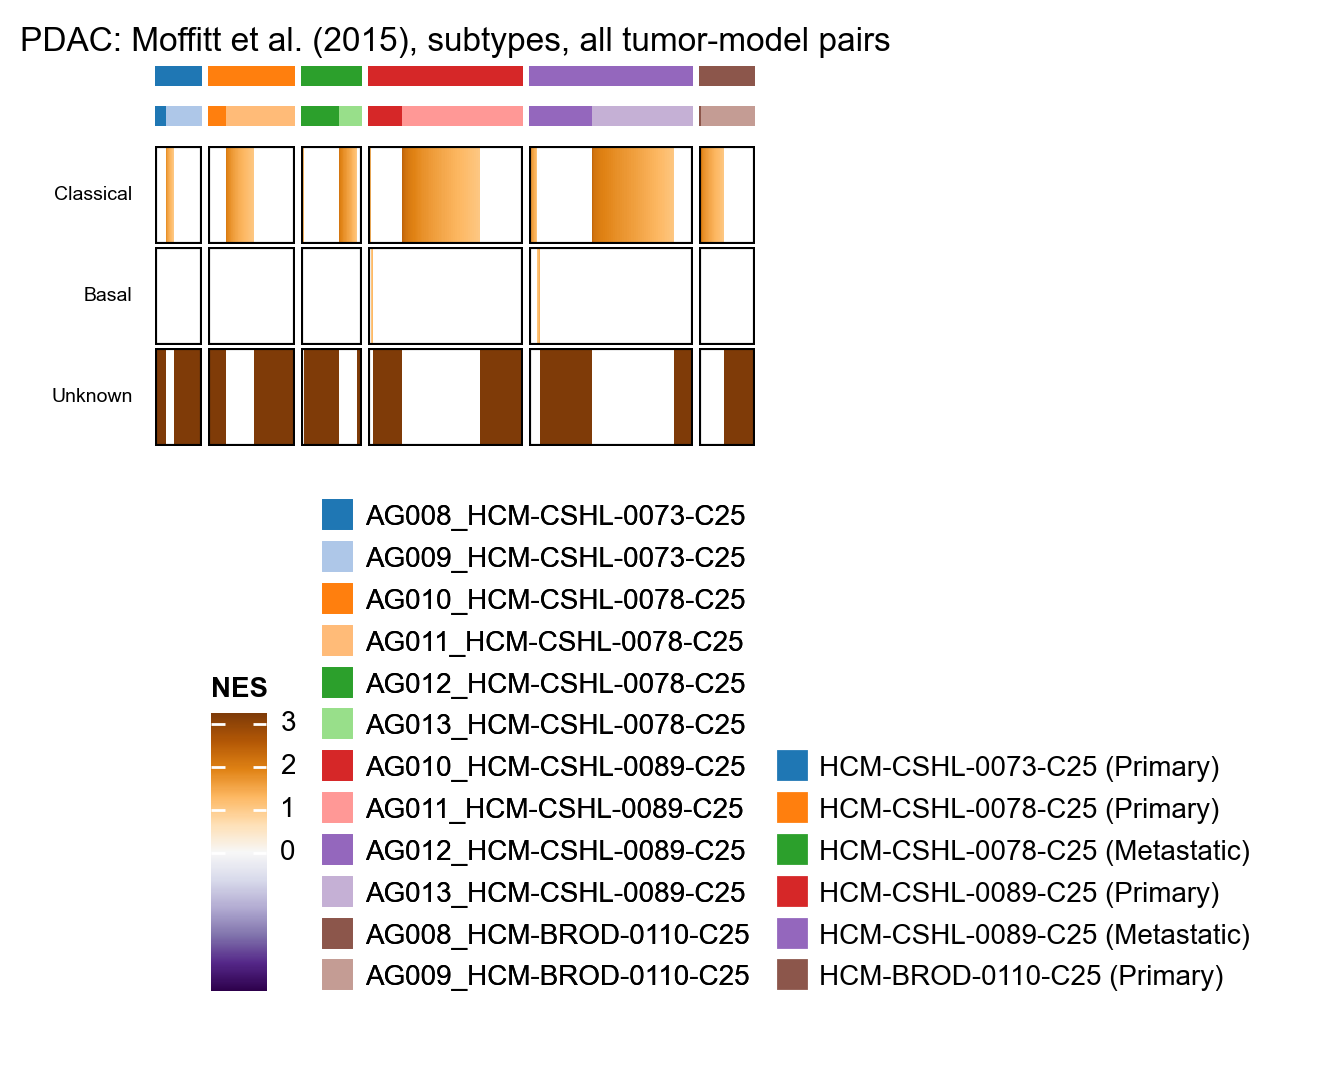

In [12]:
# Moffitt et al., 2015
nes_pvals_M = pyviper._pp._nes_to_pval_df(Moffitt_enr_nn.to_df(), lower_tail=False, adjust=False) # cell type which has highest P value 
Moffitt_enr_nn.obs["subtype"] = nes_pvals_M.apply(get_top_cell_types, axis=1, top_n = 1, pval_threshold=pval_NaRnEA) # assign cell state with lowest P values
sorted_pathways = ["Classical", "Basal"]


Moffitt_enr_nn_binary = Moffitt_enr_nn.copy()
Moffitt_enr_nn_binary = create_adata_to_heatmap(adata=Moffitt_enr_nn, subtypes=sorted_pathways, subtype_assignments=Moffitt_enr_nn.obs["subtype"], binary_output=binary_output)
extra_unknowns = list(np.nanmax(Moffitt_enr_nn_binary.X, axis=1) < 0) # rows whose max NES is < 0
Moffitt_enr_nn_binary.obs.loc[extra_unknowns,"subtype"] = "Unknown"
mask_unknown = Moffitt_enr_nn_binary.obs["subtype"] == "Unknown" # set unknowns to np.nan
Moffitt_enr_nn_binary.X[mask_unknown, :] = np.nan


# include Unknowns
range_min = np.nanmin(Moffitt_enr_nn_binary.X)
range_max = np.nanmax(Moffitt_enr_nn_binary.X)

if binary_output == True:
    unknown_val = 1
else:
    unknown_val = range_max

Moffitt_enr_nn_binary.obs["Unknown"] = np.nan
mask_unknown = ~Moffitt_enr_nn_binary.obs["subtype"].isin(sorted_pathways)
Moffitt_enr_nn_binary.obs.loc[mask_unknown, "Unknown"] = unknown_val

Moffitt_enr_nn_binary = sort_anndata_custom_var(Moffitt_enr_nn_binary, obs_col='Sample ID snRNAseq', var_names=["Classical", "Basal"], 
                                  ascending_order=[False, True])

title = f"{cohort}: Moffitt et al. (2015), subtypes, all tumor-model pairs"        
figsize = (3, 1.50)  # Squeezed x-axis with more height for y-axis labels

tab20 = plt.get_cmap("tab20")


exp = Moffitt_enr_nn_binary[:,sorted_pathways].X.T
unknown_values = Moffitt_enr_nn_binary.obs["Unknown"].values.reshape(-1,1).T
exp = np.vstack([exp, unknown_values])

if binary_output == True:
    m = ma.Heatmap(exp, cmap="Blues", vmin=0, vmax=1, height=figsize[1], width=figsize[0], rasterized=True)  # Add label for heatmap values
else:
    m = ma.Heatmap(exp, cmap="PuOr_r", vmin=-0.01, center = 0, vmax=range_max, height=figsize[1], width=figsize[0], label="NES", rasterized=True)  # Add label for heatmap values

sorted_pathways = sorted_pathways + ["Unknown"]
# Column grouping
ordering_samples = list(Moffitt_enr_nn_binary.obs["Sample ID snRNAseq"].unique())
ordering_case_types = list(Moffitt_enr_nn_binary.obs["Case_Type"].unique())
m.group_cols(Moffitt_enr_nn_binary.obs['Case_Type'].values, order=ordering_case_types)
m.group_rows(sorted_pathways, order=sorted_pathways)

# Plotters
#chunk = mp.Chunk(ordering_samples, rotation=90, align="center")
color_map = {cat: tab20(i) for i, cat in enumerate(ordering_samples)}
colormap_case = {cat: tab20(i*2) for i, cat in enumerate(ordering_case_types)}
colors = mp.Colors(list(Moffitt_enr_nn_binary.obs['Sample ID snRNAseq']), palette=color_map)
colors_case = mp.Colors(list(Moffitt_enr_nn_binary.obs['Case_Type']), palette=colormap_case)
subtypes = mp.Labels(sorted_pathways)

# Add annotations to heatmap
m.add_top(colors, size=0.1, pad=0.1)
m.add_top(colors_case, size=0.1, pad=0.1)
#m.add_top(chunk)
m.add_left(subtypes, pad=0.1)

# Legend and title
m.add_legends(side="bottom")
m.add_title(title)

m.render()
hax = m.get_main_ax()

# Add rectangles around each section
for ax in hax:
    border = Rectangle((0, 0), 1, 1, fill=False, lw=1.5, transform=ax.transAxes)
    ax.add_artist(border)

plt.show()


..and for Raghavan et al., 2021

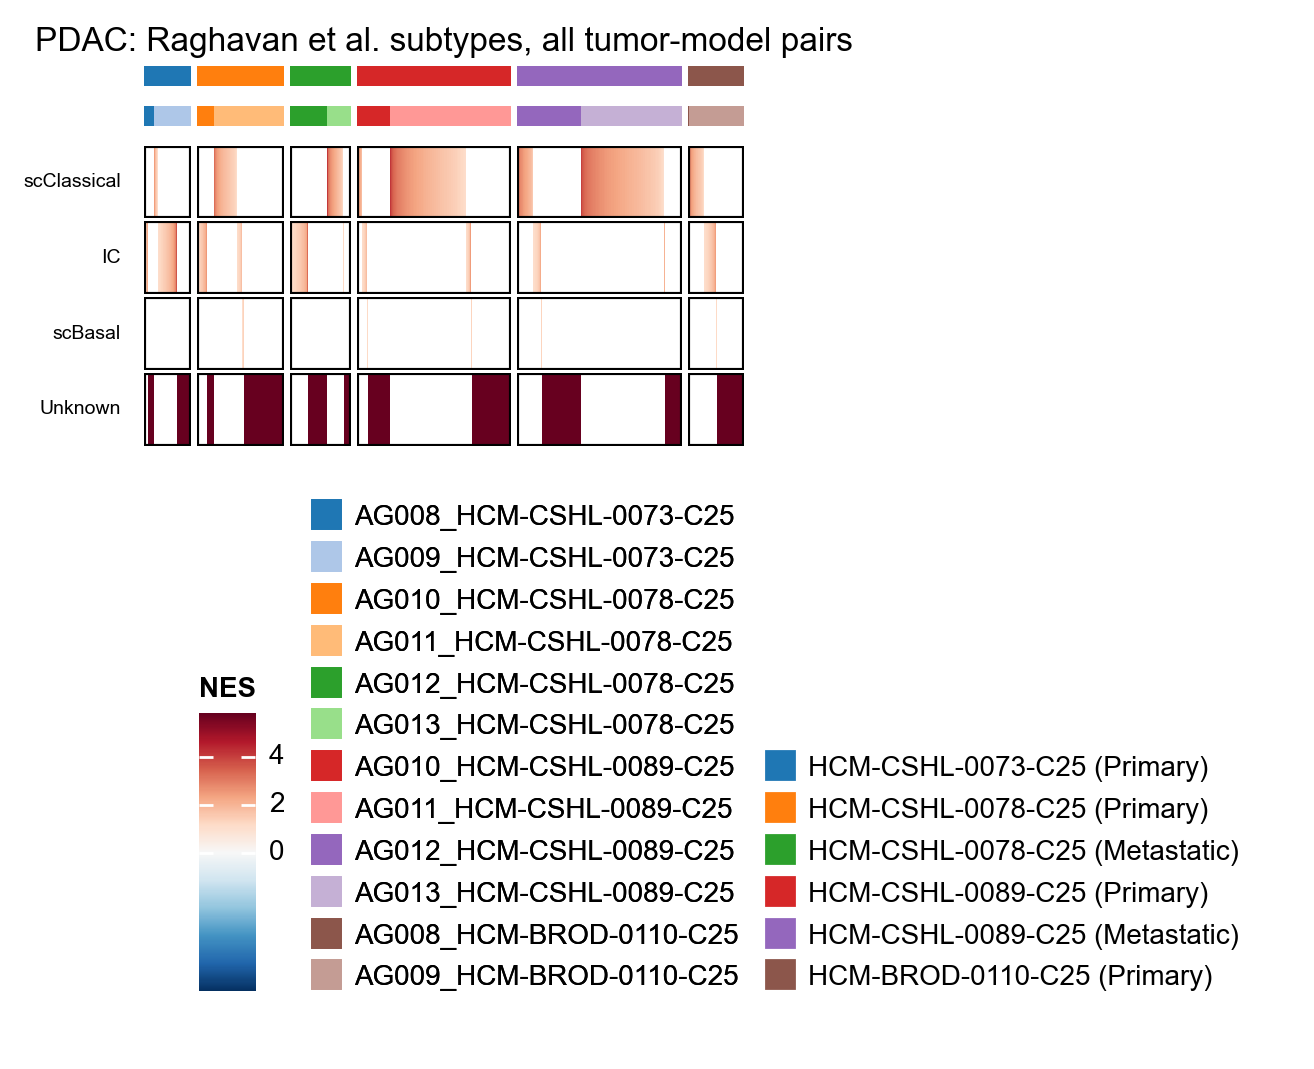

In [13]:
nes_pvals_R = pyviper._pp._nes_to_pval_df(Raghavan_enr_nn.to_df(), lower_tail=False, adjust=False) # cell type which has highest P value 
Raghavan_enr_nn.obs["subtype"] = nes_pvals_R.apply(get_top_cell_types, axis=1, top_n = 1, pval_threshold=pval_NaRnEA) # assign cell state with lowest P values
sorted_pathways = ['scClassical', 'IC', 'scBasal']


Raghavan_enr_nn_binary = Raghavan_enr_nn.copy()
Raghavan_enr_nn_binary = create_adata_to_heatmap(adata=Raghavan_enr_nn_binary, subtypes=sorted_pathways, subtype_assignments=Raghavan_enr_nn_binary.obs["subtype"], binary_output=binary_output)
extra_unknowns = list(np.nanmax(Raghavan_enr_nn_binary.X, axis=1) < 0) # rows whose max NES is < 0
Raghavan_enr_nn_binary.obs.loc[extra_unknowns,"subtype"] = "Unknown"
mask_unknown = Raghavan_enr_nn_binary.obs["subtype"] == "Unknown" # set unknowns to np.nan
Raghavan_enr_nn_binary.X[mask_unknown, :] = np.nan
# include Unknowns
range_min = np.nanmin(Raghavan_enr_nn_binary.X)
range_max = np.nanmax(Raghavan_enr_nn_binary.X)
if binary_output == True:
    unknown_val = 1
else:
    unknown_val = range_max
Raghavan_enr_nn_binary.obs["Unknown"] = np.nan
mask_unknown = ~Raghavan_enr_nn_binary.obs["subtype"].isin(sorted_pathways)
Raghavan_enr_nn_binary.obs.loc[mask_unknown, "Unknown"] = unknown_val
 
Raghavan_enr_nn_binary = sort_anndata_custom_var(Raghavan_enr_nn_binary, obs_col='Sample ID snRNAseq', 
                                      var_names=['scClassical', 'IC', 'scBasal'],
                                      ascending_order=[False, True, True ])

title = f"{cohort}: Raghavan et al. subtypes, all tumor-model pairs"        
figsize = (3, 1.50)  
tab20 = plt.get_cmap("tab20")

exp = Raghavan_enr_nn_binary[:,sorted_pathways].X.T
unknown_values = Raghavan_enr_nn_binary.obs["Unknown"].values.reshape(-1,1).T
exp = np.vstack([exp, unknown_values])

if binary_output == True:
    m = ma.Heatmap(exp, cmap="Blues", vmin=0, vmax=1, height=figsize[1], width=figsize[0], rasterized=True)  # Add label for heatmap values
else:
    m = ma.Heatmap(exp, cmap="RdBu_r", vmin=-0.01, center = 0, vmax=range_max, height=figsize[1], width=figsize[0], label="NES", rasterized=True)  # Add label for heatmap values

sorted_pathways = sorted_pathways + ["Unknown"]
# Column grouping
ordering_samples = list(Raghavan_enr_nn_binary.obs["Sample ID snRNAseq"].unique())
ordering_case_types = list(Raghavan_enr_nn_binary.obs["Case_Type"].unique())
m.group_cols(Raghavan_enr_nn_binary.obs['Case_Type'].values, order=ordering_case_types)
m.group_rows(sorted_pathways, order=sorted_pathways)

# Plotters
#chunk = mp.Chunk(ordering_samples, rotation=90, align="center")
color_map = {cat: tab20(i) for i, cat in enumerate(ordering_samples)}
colormap_case = {cat: tab20(i*2) for i, cat in enumerate(ordering_case_types)}
colors = mp.Colors(list(Raghavan_enr_nn_binary.obs['Sample ID snRNAseq']), palette=color_map)
colors_case = mp.Colors(list(Raghavan_enr_nn_binary.obs['Case_Type']), palette=colormap_case)
subtypes = mp.Labels(sorted_pathways)

# Add annotations to heatmap
m.add_top(colors, size=0.1, pad=0.1)
m.add_top(colors_case, size=0.1, pad=0.1)
#m.add_top(chunk)
m.add_left(subtypes, pad=0.1)

# Legend and title
m.add_legends(side="bottom")
m.add_title(title)

m.render()
hax = m.get_main_ax()

# Add rectangles around each section
for ax in hax:
    border = Rectangle((0, 0), 1, 1, fill=False, lw=1.5, transform=ax.transAxes)
    ax.add_artist(border)

plt.show()

### Protein Activity analysis and identification of GLS, MOS and ALS malignant cell states in malignant cells

Infer the Protein Activity at single-nucleus resolution using metaVIPER with two PAAD single-cell/single-nucleus ARACNe3 regulatory networks and four PAAD bulk networks. This step can be time-consuming. To speed up the processing, load a previously computed protein activity matrix. 


In [14]:
if run_protein_activity == True:
    # ARACNe3 network

    net_dir = f"{Work_dir}PAAD-networks/"

    TCGA_net = pyviper.Interactome("TCGA-PDAC", net_table=f"{net_dir}paad-TCGA-network.tsv")
    ICGC_net = pyviper.Interactome("ICGC-PDAC", net_table=f"{net_dir}paad-ICGC-network.tsv")
    UNC_net = pyviper.Interactome("UNC-PDAC", net_table=f"{net_dir}paad-UNC-network.tsv")
    EPITH_net = pyviper.Interactome("EPITH-PDAC", net_table=f"{net_dir}paad-EPITH-network.tsv")

    EPI_SC_net = pyviper.Interactome("EPITH-SC-PDAC", net_table=f"{net_dir}paad-EPI-SC-network.tsv")

    HCMI_SN_integrated_net = pyviper.Interactome("HCMI-SN-PDAC", net_table=f"{net_dir}hcmi-single-nucleus-tumors-nets-integrated.pkl")

    # Remove potential duplicates in the networks
    TCGA_net.net_table = TCGA_net.net_table.drop_duplicates(subset=["regulator", "target"], keep="first")
    ICGC_net.net_table = ICGC_net.net_table.drop_duplicates(subset=["regulator", "target"], keep="first")
    UNC_net.net_table = UNC_net.net_table.drop_duplicates(subset=["regulator", "target"], keep="first")
    EPITH_net.net_table = EPITH_net.net_table.drop_duplicates(subset=["regulator", "target"], keep="first")
    EPI_SC_net.net_table = EPI_SC_net.net_table.drop_duplicates(subset=["regulator", "target"], keep="first")

    HCMI_SN_integrated_net.net_table = HCMI_SN_integrated_net.net_table.drop_duplicates(subset=["regulator", "target"], keep="first")


    print("Filtering gene regulatory networks based on gene expression matrices")
    # Filter targets
    TCGA_net.filter_targets(adata_all.var_names)
    ICGC_net.filter_targets(adata_all.var_names)
    UNC_net.filter_targets(adata_all.var_names)
    EPITH_net.filter_targets(adata_all.var_names)
    EPI_SC_net.filter_targets(adata_all.var_names)

    HCMI_SN_integrated_net.filter_targets(adata_all.var_names)

    print("Pruning gene regulatory networks based on the specified number of targets")

    # Prune
    TCGA_net.prune(max_targets=n_targets_VIPER,eliminate=False)
    ICGC_net.prune(max_targets=n_targets_VIPER,eliminate=False)
    UNC_net.prune(max_targets=n_targets_VIPER,eliminate=False)
    EPITH_net.prune(max_targets=n_targets_VIPER,eliminate=False)

    EPI_SC_net.prune(max_targets=n_targets_VIPER,eliminate=False)

    HCMI_SN_integrated_net.prune(max_targets=n_targets_VIPER,eliminate=False)


    # Inferring Protein Activity using VIPER
    print("Runnig metaVIPER on single-cell networks")
    scVIPER = pyviper.viper(gex_data=adata_all, interactome=[HCMI_SN_integrated_net, EPI_SC_net], enrichment="narnea", eset_filter=False, output_as_anndata=False) # VIPER on integrated network


    print("Runnig metaVIPER on bulk networks")
    bulkVIPER = pyviper.viper(gex_data=adata_all, interactome=[TCGA_net, ICGC_net, UNC_net, EPITH_net], enrichment="narnea", eset_filter=False, output_as_anndata=False, njobs=3) # VIPER on integrated network

    # Concatenate scVIPER and bulkVIPER into a single VIPER matrix
    print("Concatenate metaVIPER matrices generated from bulk  and single cell networks")
    
    fill_genes = bulkVIPER["nes"].columns.difference(scVIPER["nes"].columns).to_list()
    PA_NES_all = scVIPER["nes"].merge(bulkVIPER["nes"].loc[:,fill_genes], left_index=True, right_index=True, how="left")

    PA_PES_all = scVIPER["pes"].merge(bulkVIPER["pes"].loc[:,fill_genes], left_index=True, right_index=True, how="left")

else:
    print("Loading protein activity matrix for all pancreatic samples")
    PA_NES_all = pd.read_csv(f"{Work_dir}PDAC-all-samples-protein-activity-ref-{reference}-NES.tsv", sep="\t", index_col=0)

# Store protein activity (NES) scores into AnnData object
PA_NES_all = pd.DataFrame(PA_NES_all, index=adata_all.obs.index)
PA_NES_all = anndata.AnnData(X=PA_NES_all, obs=adata_all.obs)


Loading protein activity matrix for all pancreatic samples


Compute dimensionality reduction on Protein Activity data

In [15]:
# Run PCA and UMAP on protein activity data
if run_dim_red == True:
    sc.tl.pca(PA_NES_all, svd_solver="arpack") # run PCA
    # Extract PCA embeddings
    pca_df = pd.DataFrame(PA_NES_all.obsm["X_pca"], index=PA_NES_all.obs.index)
    pca_df.to_csv(f"{Work_dir}data_to_upload/PDAC-all-samples-ref-{reference}-PCA.csv",index=True)
    del pca_df
else:
    print("Loading PCA coordinates")
    pca_df = pd.read_csv(f"{Work_dir}PDAC-all-samples-ref-{reference}-PCA.csv",index_col=0)
    PA_NES_all.obsm["X_pca"] = np.array(pca_df)
    del pca_df
sc.tl.embedding_density(PA_NES_all, basis='pca', groupby='Tumor or Model') # calculate density on PCA using KDE
sc.pp.neighbors(PA_NES_all, n_neighbors=NN_vector) # run NN
sc.tl.umap(PA_NES_all) # UMAP

Loading PCA coordinates


### Assign malignant cells to cellular states

Load protein activity signatures for the MOS, GLS, ALS states and preprocess the dataframe, as defined in [Laise et al.](https://www.biorxiv.org/content/10.1101/2020.10.27.357269v2)

In [16]:
# Perform subtypes enrichment for PDAC subtypes
PDAC_subtypes_path = f"{markers_dir}scSignatures4annot.csv"
PDAC_signatures = pd.read_csv(PDAC_subtypes_path) # PDAC signatures
PDAC_signatures[PDAC_signatures["regulator"].isin(list(PA_NES_all.var_names))] # subset for only regulators in the protein activity matrix 
PDAC_signatures.set_index("regulator", inplace=True)

Identify the `neg_reg` most activated and inactivated proteins in each state. Convert the pd.DataFrame to an object of class Interactome and perform filtering for NaRnEA enrichment. Malignant states with same lineage (ALS or GLS or MOS) and different MAPK activity (+/-) are collapsed into the same state. Assign cellular state based on P value.

In [17]:
# Identify top and bottom n_reg for each PDAC subtype
tmp_PDAC_subtypes = [] # initialize regulon collector
for col in PDAC_signatures.columns:
    top_n_reg = PDAC_signatures[col].nlargest(n_PDAC) # top n
    bottom_n_reg = PDAC_signatures[col].nsmallest(n_PDAC) # bottom n
    for gene, score in top_n_reg.items():
        tmp_PDAC_subtypes.append([col, gene, 1, 1])

    for gene, score in bottom_n_reg.items():
        tmp_PDAC_subtypes.append([col, gene, -1, 1])

PDAC_subtypes_reference = pd.DataFrame(tmp_PDAC_subtypes, columns=["regulator", "target", "mor", "likelihood"])
PDAC_subtypes_reference = pyviper.Interactome(cohort, net_table=PDAC_subtypes_reference)

PDAC_subtypes_reference.filter_targets(PA_NES_all.var_names) # filter names

PDAC_enrichment_all = pyviper.viper(gex_data=PA_NES_all, interactome=PDAC_subtypes_reference,
                                    enrichment="narnea", eset_filter=False,
                                    store_input_data=False, min_targets=1, verbose=False) 

# Coarse grain and subtype assignment
PDAC_enrichment_all_cg = PDAC_enrichment_all.to_df()

# For each pair of M+ and M- columns, take the max value
PDAC_enrichment_all_cg['ALS'] = PDAC_enrichment_all_cg[['ALS (M+)', 'ALS (M-)']].max(axis=1)
PDAC_enrichment_all_cg['GLS'] = PDAC_enrichment_all_cg[['GLS (M+)', 'GLS (M-)']].max(axis=1)
PDAC_enrichment_all_cg['MOS'] = PDAC_enrichment_all_cg[['MOS (M+)', 'MOS (M-)']].max(axis=1)
PDAC_enrichment_all_cg = PDAC_enrichment_all_cg.drop(columns=PDAC_enrichment_all_cg.filter(regex=r'\(M[+-]\)').columns) # drop columns containing M+ and M-

PDAC_enrichment_all_cg = anndata.AnnData(X=PDAC_enrichment_all_cg, obs=PDAC_enrichment_all.obs)

# subtype assignment
nes_pvals = pyviper._pp._nes_to_pval_df(PDAC_enrichment_all_cg.to_df(), lower_tail=False, adjust=False) # cell type which has highest P value 
PDAC_enrichment_all_cg.obs["PA_subtype_assignment"] = nes_pvals.apply(get_top_cell_types, axis=1, top_n = 1, pval_threshold=pval_NaRnEA) # assign cell state with lowest P values

Removed 4 targets.


/users/lz2841/.conda/envs/scRNA-seq/lib/python3.11/site-packages/pyviper/NaRnEA/NaRnEA_classic.py:200: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  filtered_table['mor'].replace(1 ,0.999, inplace= True)


Display cell state assignment

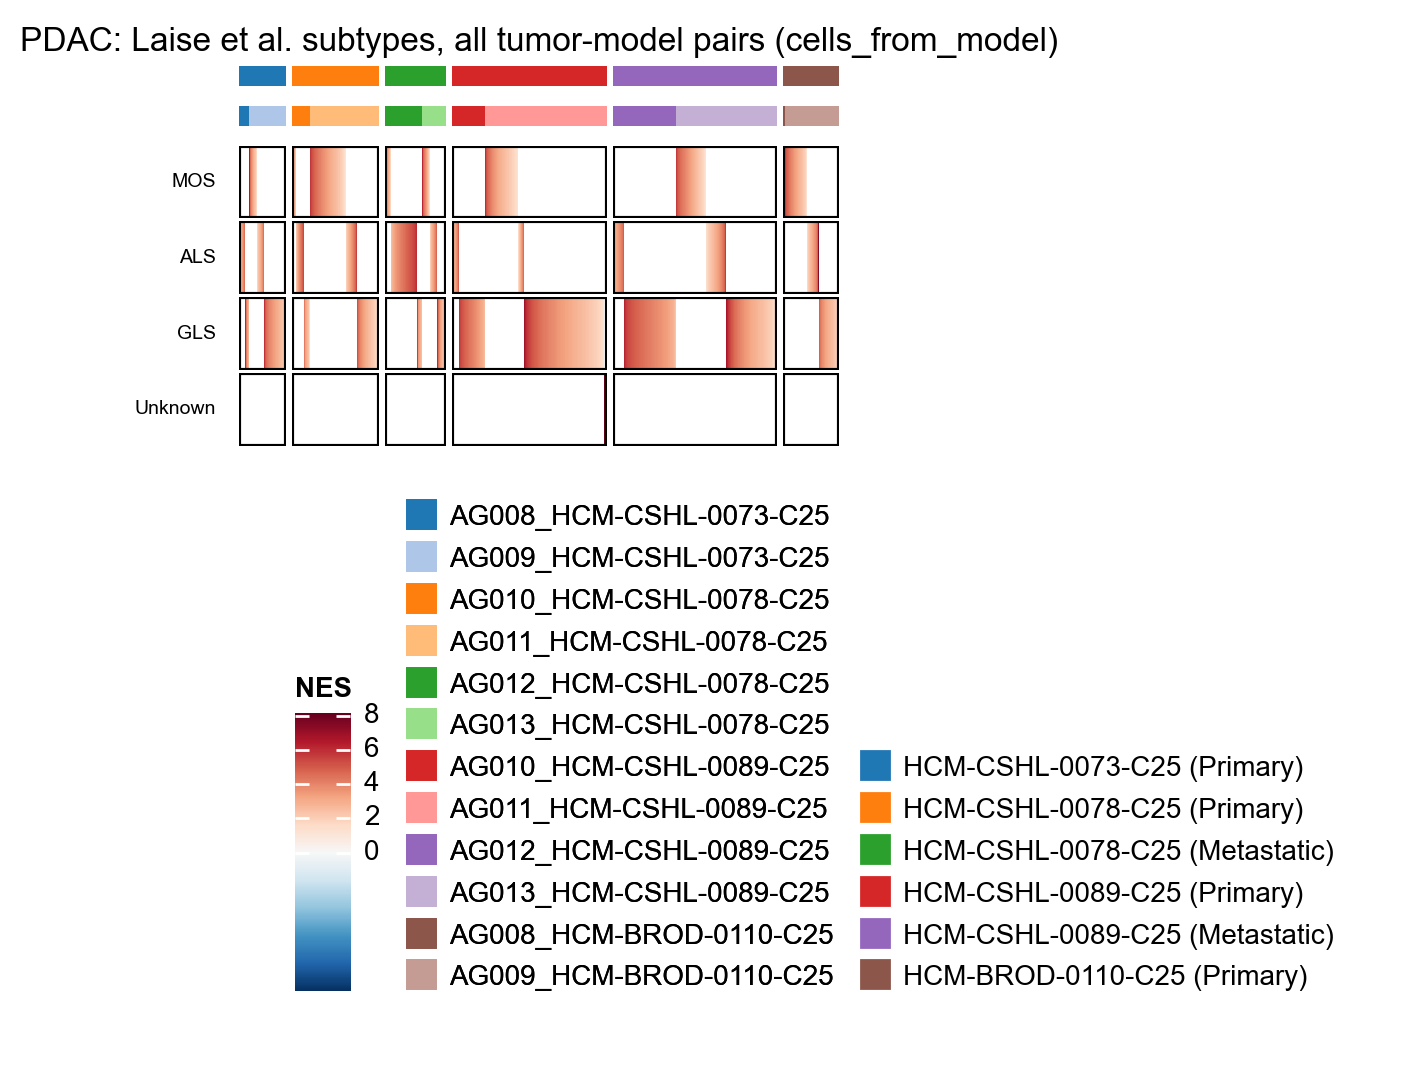

In [18]:
# Show PDAC subtype enrichment only for cells that have been assigned to a state
subtypes = ['MOS', 'ALS', 'GLS']
PDAC_enrichment_all_binary = PDAC_enrichment_all_cg.copy()
PDAC_enrichment_all_binary = create_adata_to_heatmap(adata=PDAC_enrichment_all_binary, subtypes=subtypes, subtype_assignments=PDAC_enrichment_all_binary.obs["PA_subtype_assignment"], binary_output=binary_output)
mask_unknown = PDAC_enrichment_all_binary.obs["PA_subtype_assignment"] == "Unknown" # set unknowns to np.nan
PDAC_enrichment_all_binary.X[mask_unknown, :] = np.nan


# include Unknowns
range_min = np.nanmin(PDAC_enrichment_all_binary.X)
range_max = np.nanmax(PDAC_enrichment_all_binary.X)

if binary_output == True:
    unknown_val = 1
else:
    unknown_val = range_max

PDAC_enrichment_all_binary.obs["Unknown"] = np.nan
mask_unknown = ~PDAC_enrichment_all_binary.obs["PA_subtype_assignment"].isin(subtypes)
PDAC_enrichment_all_binary.obs.loc[mask_unknown, "Unknown"] = unknown_val
 
PDAC_enrichment_all_binary = sort_anndata_custom_var(PDAC_enrichment_all_binary, obs_col='Sample ID snRNAseq', # sort AnnData based on features
                                      var_names=['MOS', 'ALS', 'GLS'],
                                      ascending_order=[False, True, False])

title = f"{cohort}: Laise et al. subtypes, all tumor-model pairs ({reference})"        
figsize = (3, 1.50)  

tab20 = plt.get_cmap("tab20")

# Prepare data
sorted_pathways = ["MOS", "ALS", "GLS"]
exp = PDAC_enrichment_all_binary[:,sorted_pathways].X.T
unknown_values = PDAC_enrichment_all_binary.obs["Unknown"].values.reshape(-1,1).T
exp = np.vstack([exp, unknown_values])

if binary_output == True:
    m = ma.Heatmap(exp, cmap="Blues", vmin=0, vmax=1, height=figsize[1], width=figsize[0], rasterized=True)  # Add label for heatmap values
else:
    m = ma.Heatmap(exp, cmap="RdBu_r", vmin=-0.01, center = 0, vmax=range_max, height=figsize[1], width=figsize[0], label="NES", rasterized=True)  # Add label for heatmap values

sorted_pathways = sorted_pathways + ["Unknown"]
# Column grouping
ordering_samples = list(PDAC_enrichment_all_binary.obs["Sample ID snRNAseq"].unique())
ordering_case_types = list(PDAC_enrichment_all_binary.obs["Case_Type"].unique())
m.group_cols(PDAC_enrichment_all_binary.obs['Case_Type'].values, order=ordering_case_types)
m.group_rows(sorted_pathways, order=sorted_pathways)

# Plotters
#chunk = mp.Chunk(ordering_samples, rotation=90, align="center")
color_map = {cat: tab20(i) for i, cat in enumerate(ordering_samples)}
colormap_case = {cat: tab20(i*2) for i, cat in enumerate(ordering_case_types)}
colors = mp.Colors(list(PDAC_enrichment_all_binary.obs['Sample ID snRNAseq']), palette=color_map)
colors_case = mp.Colors(list(PDAC_enrichment_all_binary.obs['Case_Type']), palette=colormap_case)
subtypes = mp.Labels(sorted_pathways)

# Add annotations to heatmap
m.add_top(colors, size=0.1, pad=0.1)
m.add_top(colors_case, size=0.1, pad=0.1)
#m.add_top(chunk)
m.add_left(subtypes, pad=0.1)

# Legend and title
m.add_legends(side="bottom")
m.add_title(title)

m.render()
hax = m.get_main_ax()

# Add rectangles around each section
for ax in hax:
    border = Rectangle((0, 0), 1, 1, fill=False, lw=1.5, transform=ax.transAxes)
    ax.add_artist(border)

plt.show()

Visualize cell density on the PCA projection and Normalized Enrichment Scores (NES) for the ALS, MOS and GLS cell states.

['#8dd3c7', '#ffffb3']


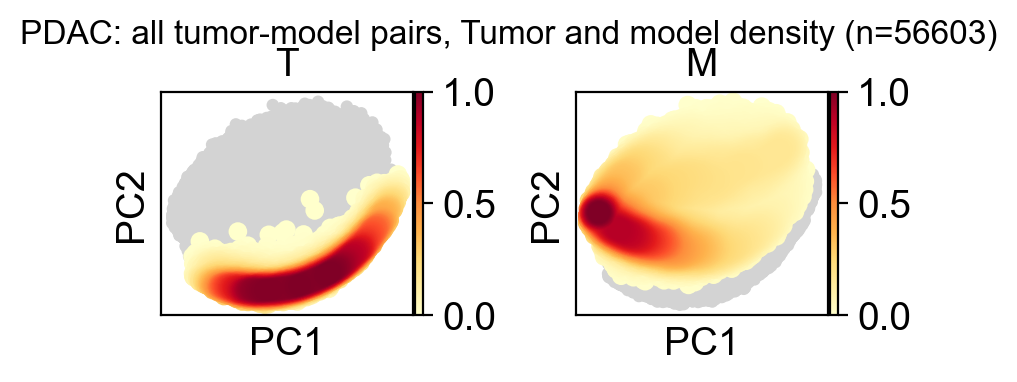

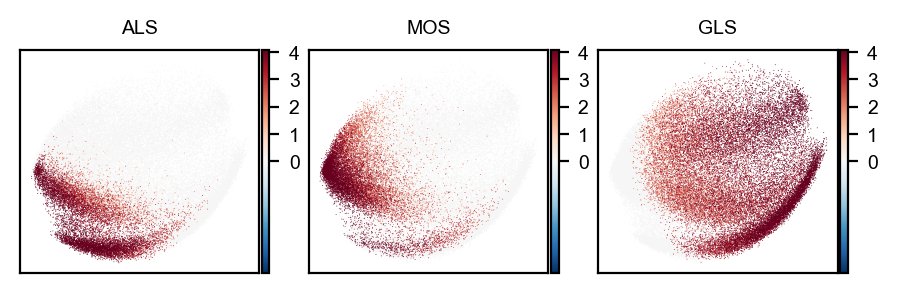

In [19]:
PDAC_subtypes_colormap = {
    'ALS': '#3182BD',   # Blue
    'GLS': '#FEAF6B',   # Orange
    'MOS': '#9E9AC9',   # Violet
    'Unknown': "#8c564a", # Brown
}
PDAC_enrichment_all_cg.obs["PA_subtype_assignment"] = pd.Categorical(PDAC_enrichment_all_cg.obs["PA_subtype_assignment"])
PDAC_enrichment_all_cg.uns["PA_subtype_assignment_colors"] = [PDAC_subtypes_colormap[ct] for ct in PDAC_enrichment_all_cg.obs["PA_subtype_assignment"].cat.categories if ct in PDAC_subtypes_colormap]
PA_NES_all.obs = PA_NES_all.obs.merge(PDAC_enrichment_all_cg.to_df(), left_index=True, right_index=True, how="left") # include the enrichment scores for all the subtypes
PA_NES_all.obs = PA_NES_all.obs.merge(PDAC_enrichment_all_cg.obs["PA_subtype_assignment"], left_index=True, right_index=True, how="left") # include the subtypes assignment
PA_NES_all.uns["PA_subtype_assignment_colors"] = [PDAC_subtypes_colormap[ct] for ct in PA_NES_all.obs["PA_subtype_assignment"].cat.categories if ct in PDAC_subtypes_colormap]

PA_NES_all.obs["Tumor or Model"] = PA_NES_all.obs["Tumor or Model"].astype('category')
PA_NES_all.obs["Tumor or Model"].cat.set_categories(['T', 'M'], ordered=True)


# NES - PCA and UMAP visualization

range_max = min([0.5*PA_NES_all.obs[["ALS", "MOS", "GLS"]].max().max(), 10])

n_cells = PA_NES_all.shape[0]
pt_size = 12000*2/n_cells


# Define the specific colors you want to use
PA_NES_all.obs["Tumor or Model"] = PA_NES_all.obs["Tumor or Model"].cat.reorder_categories(["T", "M"], ordered=True)


T_M_colors = {
    "T": "#8dd3c7",  # Green for Tumor (T)
    "M": "#ffffb3",  # Yellow for Model (M)
}

# Assign colors to PA_NES_all
PA_NES_all.uns["Tumor or Model_colors"] = [
    T_M_colors[ct] for ct in PA_NES_all.obs["Tumor or Model"].cat.categories if ct in T_M_colors
]

# Verify the color assignment
print(PA_NES_all.uns["Tumor or Model_colors"])


# density
title = f"PDAC: all tumor-model pairs, Tumor and model density (n={n_cells})"
with rc_context({'figure.figsize': (1.45, 1.45)}):
    sc.pl.embedding_density(PA_NES_all, basis='pca', key='pca_density_Tumor or Model', frameon=True, # add_outline=True
                            group=['T', 'M'], wspace=0.5, show=False, legend_fontsize=7, legend_fontweight="normal")
    plt.suptitle(title, fontsize=12, y=1.15)
    plt.show()


# Show the colored NES only for the assigned subtype
PA_NES_all.obs.loc[PA_NES_all.obs["PA_subtype_assignment"] != "ALS", "ALS"] = 0
PA_NES_all.obs.loc[PA_NES_all.obs["PA_subtype_assignment"] != "GLS", "GLS"] = 0
PA_NES_all.obs.loc[PA_NES_all.obs["PA_subtype_assignment"] != "MOS", "MOS"] = 0
PA_NES_all.obs.loc[PA_NES_all.obs["PA_subtype_assignment"] == "Unknown", ["ALS", "GLS", "MOS"]] = 0



# NES only assigned- PCA
# ALS, MOS, GLS
title = f"PDAC: all tumor-model pairs, protein activity (n={n_cells})"
with rc_context({'figure.figsize': (1.6, 1.45),
                'font.family': 'Arial',  # Set font family to Arial
                'font.size': 7,  # Set font size to 12
                'axes.labelsize': 7,  # Axis label font size
                'xtick.labelsize': 7,  # X-axis tick font size
                'ytick.labelsize': 7   # Y-axis tick font size
                }):   
    sc.pl.embedding(PA_NES_all, basis="pca",color = ["ALS", "MOS", "GLS"],
                    cmap="RdBu_r", size=pt_size, add_outline=False, frameon=True, wspace=0.1, 
                    vcenter=0, vmin=-1e-6, vmax=range_max, show=False, ncols=3, legend_fontweight="normal", legend_fontsize=7)
    # Modify the title font size
    for ax in plt.gcf().axes:
        if ax.get_title():  # Check if the title exists
            ax.title.set_fontsize(7)  # Set title font size to 7
    for ax in plt.gcf().axes:
        ax.set_xlabel('')  # Clear x-axis label
        ax.set_ylabel('')  # Clear y-axis label
    plt.tight_layout()  # Adjust rect to leave space for suptitle
    plt.show()

Display transcriptional state assignments at single nucleus level.

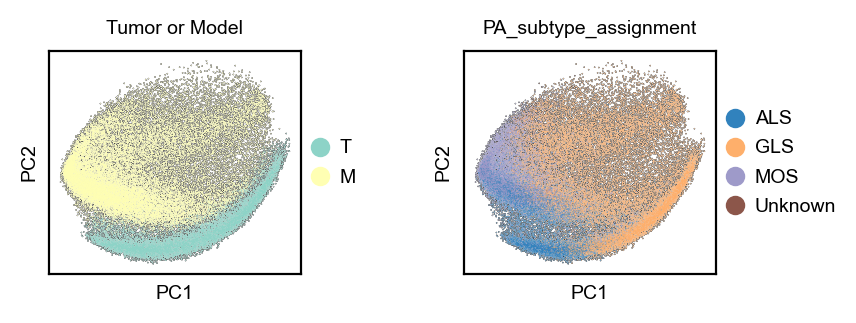

In [20]:
# NES - PCA single panels
# PA subtypes + Tumor or Model
title = f"PDAC: all tumor-model pairs, protein activity (n={n_cells})"    
with rc_context({
        'figure.figsize': (1.45, 1.45),
        'font.family': 'Arial',  # Set font family to Arial
        'font.size': 7,  # Set font size to 12
        'axes.labelsize': 7,  # Axis label font size
        'xtick.labelsize': 7,  # X-axis tick font size
        'ytick.labelsize': 7   # Y-axis tick font size
    }):        
    sc.pl.embedding(PA_NES_all, basis="pca",color = ["Tumor or Model", "PA_subtype_assignment"], 
                    cmap="RdBu_r", size=pt_size, add_outline=True, frameon=True, wspace=0.5, 
                    vcenter=0, vmin=range_min, vmax=range_max, show=False, ncols=2, legend_fontsize=7, legend_fontweight="normal")
    #plt.suptitle(title, fontsize=20, y=1)
    for ax in plt.gcf().axes:
        if ax.get_title():  # Check if the title exists
            ax.title.set_fontsize(7)  # Set title font size to 7
    plt.show()

Display subtype assignments for two tumor-model pairs, from cases 078 and 089.

['AG010_HCM-CSHL-0078-C25', 'AG011_HCM-CSHL-0078-C25']


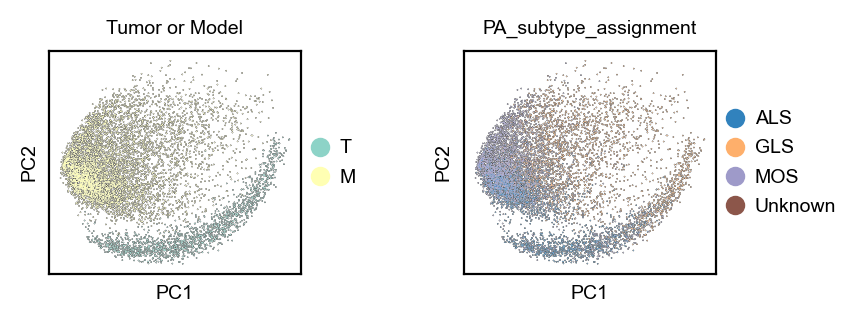

['AG010_HCM-CSHL-0089-C25', 'AG011_HCM-CSHL-0089-C25']


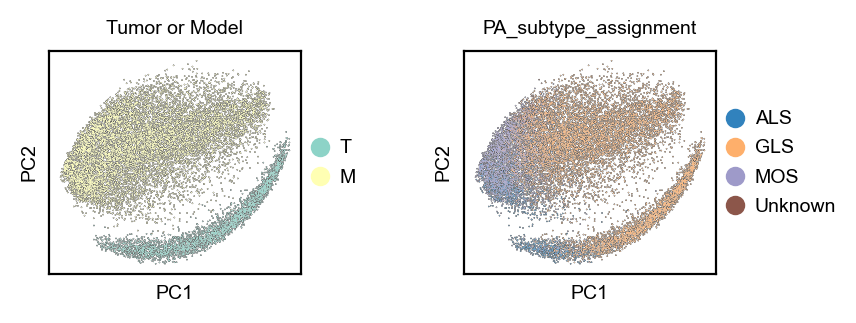

In [21]:
# NES - PCA - sample pairs
sample_pairs = [['AG010_HCM-CSHL-0078-C25', 'AG011_HCM-CSHL-0078-C25'], ['AG010_HCM-CSHL-0089-C25', 'AG011_HCM-CSHL-0089-C25']]
               
for these_samples in sample_pairs:
    print(these_samples)

    these_samples_str = re.sub(r"[\[\]]", "", str(these_samples))

     # NES - PCA single panels
    # PA subtypes
    title = f"PDAC: all tumor-model pairs, protein activity (n={n_cells})"    
    with rc_context({
        'figure.figsize': (1.45, 1.45),
        'font.family': 'Arial',  # Set font family to Arial
        'font.size': 7,  # Set font size to 12
        'axes.labelsize': 7,  # Axis label font size
        'xtick.labelsize': 7,  # X-axis tick font size
        'ytick.labelsize': 7   # Y-axis tick font size
        }):        
        sc.pl.embedding(PA_NES_all[PA_NES_all.obs["Sample ID snRNAseq"].isin(these_samples)], basis="pca",color = ["Tumor or Model", "PA_subtype_assignment"], 
                    cmap="RdBu_r", size=pt_size, add_outline=True, frameon=True, wspace=0.5, 
                    vcenter=0, vmin=range_min, vmax=range_max, show=False, ncols=2, legend_fontsize=7, legend_fontweight="normal")
    for ax in plt.gcf().axes:
        if ax.get_title():  # Check if the title exists
            ax.title.set_fontsize(7)  # Set title font size to 7
    plt.show()

Summarize subtype assignments across all tumor-model pairs

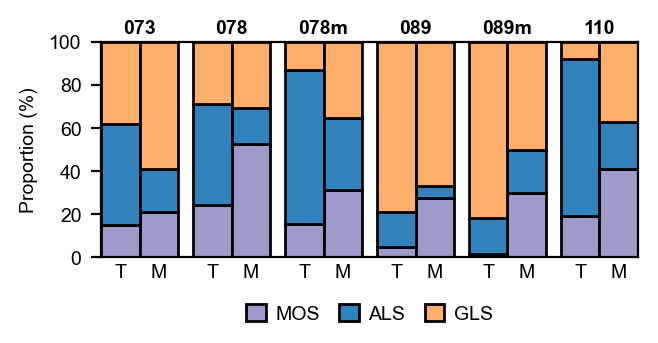

In [22]:
col_assignment = "PA_subtype_assignment"
if include_unknown_barplots == True:
    sorted_pathways = ['MOS', 'ALS', 'GLS', 'Unknown'] # each attribute to plot in the radar chart
    PDAC_subtypes_colormap = {
        'ALS': '#3182BD',   # Blue
        'GLS': '#FEAF6B',   # Orange
        'MOS': '#9E9AC9',   # Violet
        'Unknown': "#8c564a", # Brown
    }
elif include_unknown_barplots == False:
    sorted_pathways = ['MOS', 'ALS', 'GLS'] # each attribute to plot in the radar chart
    PDAC_subtypes_colormap = {
        'ALS': '#3182BD',   # Blue
        'GLS': '#FEAF6B',   # Orange
        'MOS': '#9E9AC9',   # Violet
    }
num_vars = len(sorted_pathways)



# Prepare the dataframe to plot as a barplots 
df_radar_all = pd.DataFrame()
n_cells_all = pd.DataFrame()
for sample in samples:
    df_radar = pd.DataFrame(PA_NES_all.obs.loc[PA_NES_all.obs["Sample ID snRNAseq"] == sample, col_assignment].value_counts()).T
    df_radar = df_radar.reindex(columns=sorted_pathways, fill_value=0)
    n_cells = pd.DataFrame({"sample": [sample], "n_cells": [df_radar.sum().sum()]})
    #df_radar = df_radar[sorted_pathways]
    df_radar.index = [sample]
    df_radar = df_radar.div(df_radar.sum(axis=1), axis=0) * 100
    df_radar_all = pd.concat([df_radar_all, df_radar])
    n_cells_all = pd.concat([n_cells_all, n_cells])

group_labels_tmp = [simplify_identifier(idx) for idx in df_radar_all.index] # group labels for plotting
# attach suffix 
counter = {}
group_labels = []
for label in group_labels_tmp:
    if label not in counter:
        counter[label] = 0
    counter[label] += 1
    # Determine suffix based on count
    if counter[label] <= 2:
        suffix = ""
    else:
        suffix = "m"
    
    # Add the updated label
    group_labels.append(f"{label}{suffix}" if label in ['078', '089'] else f"{label}")
group_labels = list(dict.fromkeys(group_labels)) # group labels for plotting


# J.2) Generate barplots
plot_grouped_stacked_bar(
    df_radar_all, 
    figsize=(3.3, 1.85), 
    title="", 
    colormap=PDAC_subtypes_colormap, 
    group_labels=group_labels, 
    group_gap=0.15, 
    tick_label_size=7,  # Adjust tick label size
    title_size=7,       # Adjust title size
    legend_size=7,      # Adjust legend size
    axis_label_size=7,  # Adjust axis label size
    n_cells_dataframe = n_cells_all, 
)


